# Analisis Kompresi Gambar Menggunakan Algoritma JPEG dengan Python Pillow

**Nama:** Muhamad Zidan Indratama  
**NPM:** 50422968  
**Kelas:** 4IA08  
**Mata Kuliah:** Sistem Multimedia

## Pendahuluan

Kompresi gambar penting dalam multimedia karena dapat mengurangi ukuran file sehingga penyimpanan dan pengiriman data menjadi lebih efisien. Pada pengujian ini, gambar asli dibandingkan dengan gambar hasil kompresi untuk melihat perubahan ukuran file dan kualitas visual.

## Landasan Teori Singkat

Kompresi gambar adalah proses mengurangi ukuran file gambar. Kompresi dapat bersifat **lossless**, yaitu kualitas tetap sama, atau **lossy**, yaitu sebagian informasi gambar dikurangi agar ukuran file menjadi lebih kecil.

JPEG termasuk metode kompresi **lossy**. Secara umum, proses JPEG melibatkan konversi warna RGB ke YCbCr, pembagian gambar ke blok 8x8 piksel, transformasi DCT, quantization, dan entropy coding. Tahap quantization biasanya paling berpengaruh terhadap penurunan ukuran dan kualitas gambar.

Selain rasio kompresi, kualitas hasil juga dapat dinilai dengan **MSE** dan **PSNR**. MSE mengukur rata-rata kuadrat perbedaan pixel; semakin kecil nilainya, semakin mirip gambar hasil dengan gambar asli. PSNR mengukur kualitas berdasarkan galat kompresi; semakin tinggi nilainya, semakin baik kualitas gambar secara kuantitatif.

## Setup Kode

Cell berikut menyiapkan library dan folder yang digunakan untuk membaca gambar asli, menyimpan hasil kompresi, dan menyimpan tabel hasil pengujian.

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_DIR = PROJECT_ROOT / "data" / "input" / "original"
OUTPUT_DIR = PROJECT_ROOT / "data" / "output" / "compressed"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png"}
JPEG_QUALITY = 60

print(f"Project root: {PROJECT_ROOT}")
print(f"Folder input: {INPUT_DIR}")
print(f"Folder output: {OUTPUT_DIR}")

Project root: C:\zidanindratama\kuliah\semester-8\06-sistem-multimedia\minggu-11\project-kompresi-gambar
Folder input: C:\zidanindratama\kuliah\semester-8\06-sistem-multimedia\minggu-11\project-kompresi-gambar\data\input\original
Folder output: C:\zidanindratama\kuliah\semester-8\06-sistem-multimedia\minggu-11\project-kompresi-gambar\data\output\compressed


## Fungsi Kompresi

Fungsi ini membaca gambar dari folder input, mengubahnya ke mode RGB jika diperlukan, lalu menyimpan hasilnya sebagai JPEG dengan kualitas 60. Nilai kualitas yang lebih kecil biasanya menghasilkan ukuran file lebih kecil, tetapi kualitas visual juga dapat menurun.

In [2]:
def ukuran_kb(path):
    return path.stat().st_size / 1024


def format_kb(value):
    return f"{value:,.2f} KB"


def convert_to_rgb(image):
    if image.mode in ("RGBA", "LA") or (image.mode == "P" and "transparency" in image.info):
        background = Image.new("RGB", image.size, (255, 255, 255))
        rgba_image = image.convert("RGBA")
        background.paste(rgba_image, mask=rgba_image.split()[-1])
        return background
    return image.convert("RGB")


def hitung_mse_psnr(original_path, compressed_path):
    with Image.open(original_path) as original_image, Image.open(compressed_path) as compressed_image:
        original_rgb = convert_to_rgb(original_image)
        compressed_rgb = convert_to_rgb(compressed_image)

        original_array = np.asarray(original_rgb, dtype=np.float64)
        compressed_array = np.asarray(compressed_rgb, dtype=np.float64)

    mse = np.mean((original_array - compressed_array) ** 2)
    psnr = math.inf if mse == 0 else 20 * math.log10(255.0 / math.sqrt(mse))
    return mse, psnr


def kompresi_gambar(image_path, quality=JPEG_QUALITY):
    output_path = OUTPUT_DIR / f"{image_path.stem}_compressed_q{quality}.jpg"

    with Image.open(image_path) as image:
        image_rgb = convert_to_rgb(image)
        image_rgb.save(output_path, "JPEG", quality=quality, optimize=True)

    ukuran_awal = ukuran_kb(image_path)
    ukuran_kompresi = ukuran_kb(output_path)
    rasio_kompresi = (1 - (ukuran_kompresi / ukuran_awal)) * 100 if ukuran_awal else 0

    mse, psnr = hitung_mse_psnr(image_path, output_path)

    return {
        "Nama File": image_path.name,
        "File Hasil": output_path.name,
        "Ukuran Awal": format_kb(ukuran_awal),
        "Ukuran Hasil Kompresi": format_kb(ukuran_kompresi),
        "Jenis Kompresi": "JPEG Lossy",
        "Rasio Kompresi (%)": round(rasio_kompresi, 2),
        "MSE": round(mse, 2),
        "PSNR (dB)": "inf" if math.isinf(psnr) else round(psnr, 2),
        "Keterangan Kualitas": "Perlu evaluasi visual manual",
        "Path Asli": str(image_path),
        "Path Hasil": str(output_path),
    }

## Proses Pengujian

Masukkan minimal tiga gambar ke folder `data/input/original/`, lalu jalankan cell ini. Gambar dengan ekstensi `.jpg`, `.jpeg`, dan `.png` akan diproses otomatis.

In [3]:
image_files = sorted(
    path for path in INPUT_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in SUPPORTED_EXTENSIONS
)

if len(image_files) < 3:
    print(f"Peringatan: baru ada {len(image_files)} gambar. Untuk laporan UAS, gunakan minimal 3 gambar.")

records = [kompresi_gambar(image_path) for image_path in image_files]
print(f"Jumlah gambar diproses: {len(records)}")

Jumlah gambar diproses: 3


## Tabel Hasil

Tabel berikut menampilkan perbandingan ukuran file sebelum dan sesudah kompresi. Rasio kompresi menunjukkan persentase pengurangan ukuran file. MSE dan PSNR digunakan untuk melihat perbedaan kualitas secara kuantitatif.

In [4]:
columns = [
    "Nama File",
    "File Hasil",
    "Ukuran Awal",
    "Ukuran Hasil Kompresi",
    "Jenis Kompresi",
    "Rasio Kompresi (%)",
    "MSE",
    "PSNR (dB)",
    "Keterangan Kualitas",
]

df = pd.DataFrame(records)
if df.empty:
    df = pd.DataFrame(columns=columns)
else:
    df = df[columns]

display(df)

,Nama File,File Hasil,Ukuran Awal,Ukuran Hasil Kompresi,Jenis Kompresi,Rasio Kompresi (%),MSE,PSNR (dB),Keterangan Kualitas
0,01-manusia.jpg,01-manusia_compressed_q60.jpg,"4,274.61 KB","1,863.69 KB",JPEG Lossy,56.40,34.94,32.70,Perlu evaluasi visual manual
1,02-pemandangan.jpg,02-pemandangan_compressed_q60.jpg,"3,903.40 KB","2,195.22 KB",JPEG Lossy,43.76,17.56,35.69,Perlu evaluasi visual manual
2,03-teks.jpg,03-teks_compressed_q60.jpg,"4,748.37 KB","2,666.65 KB",JPEG Lossy,43.84,27.05,33.81,Perlu evaluasi visual manual


## Preview Visual

Preview ini menampilkan gambar asli dan hasil kompresi secara berdampingan. Bagian ini membantu menilai apakah detail, warna, atau ketajaman gambar berubah setelah kompresi.

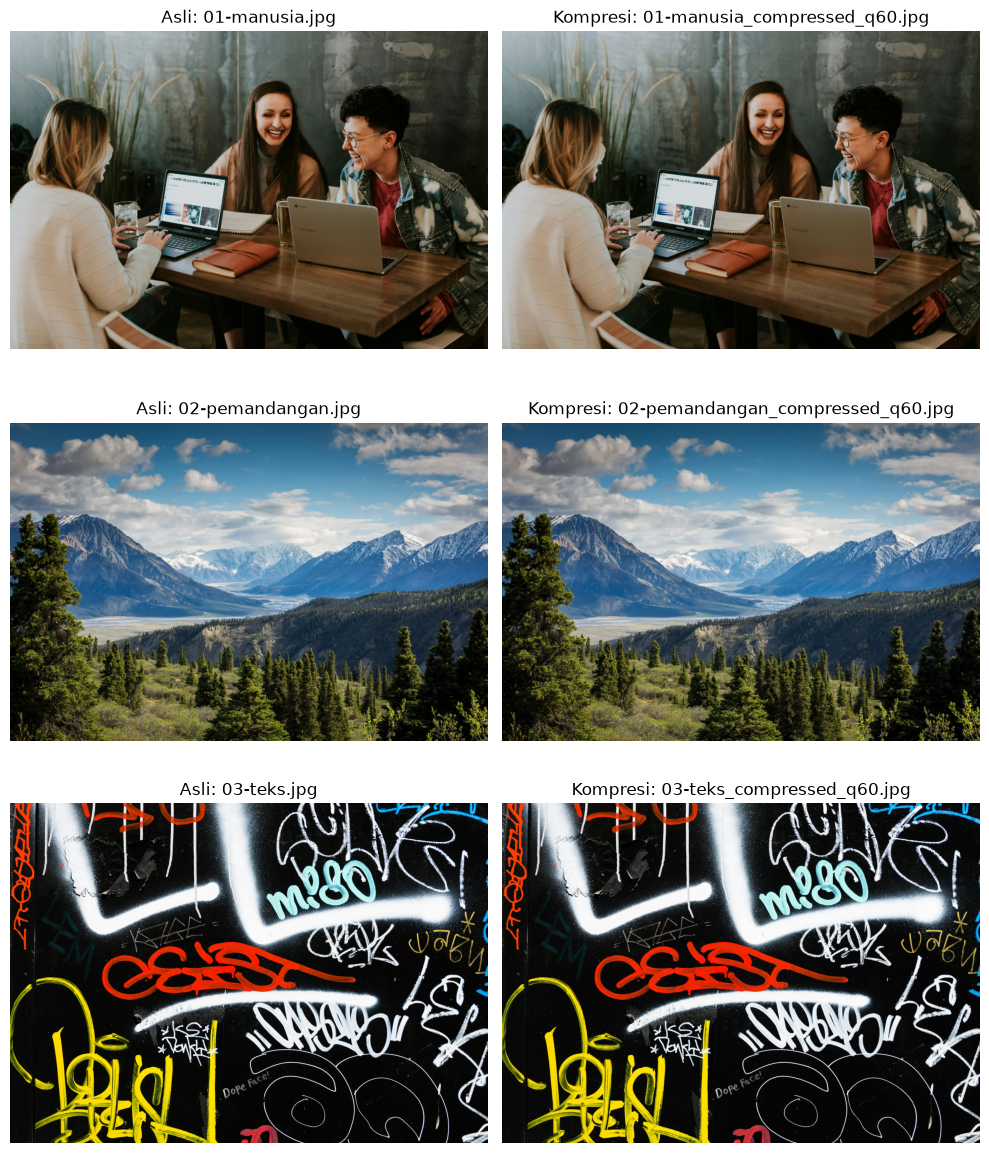

In [5]:
if not records:
    display(Markdown("Belum ada gambar untuk ditampilkan. Tambahkan gambar ke folder `data/input/original/`."))
else:
    fig, axes = plt.subplots(len(records), 2, figsize=(10, 4 * len(records)))
    if len(records) == 1:
        axes = [axes]

    for row_axes, record in zip(axes, records):
        original_image = Image.open(record["Path Asli"])
        compressed_image = Image.open(record["Path Hasil"])

        row_axes[0].imshow(original_image)
        row_axes[0].set_title(f"Asli: {record['Nama File']}")
        row_axes[0].axis("off")

        row_axes[1].imshow(compressed_image)
        row_axes[1].set_title(f"Kompresi: {record['File Hasil']}")
        row_axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## Kesimpulan Singkat

Berdasarkan hasil pengujian, kompresi JPEG dengan Pillow dapat mengurangi ukuran file gambar. Semakin besar rasio kompresi, semakin besar penghematan ukuran file. Namun, karena JPEG bersifat lossy, kualitas visual dapat mengalami penurunan terutama pada detail halus, tepi objek, atau area dengan gradasi warna.

## Export Hasil

Cell terakhir menyimpan tabel hasil pengujian ke format CSV dan Markdown agar mudah digunakan pada laporan.

In [6]:
csv_path = RESULTS_DIR / "hasil_pengujian.csv"
markdown_path = RESULTS_DIR / "hasil_pengujian.md"

df.to_csv(csv_path, index=False)
markdown_path.write_text(df.to_markdown(index=False), encoding="utf-8")

print(f"CSV tersimpan di: {csv_path}")
print(f"Markdown tersimpan di: {markdown_path}")

CSV tersimpan di: C:\zidanindratama\kuliah\semester-8\06-sistem-multimedia\minggu-11\project-kompresi-gambar\data\results\hasil_pengujian.csv
Markdown tersimpan di: C:\zidanindratama\kuliah\semester-8\06-sistem-multimedia\minggu-11\project-kompresi-gambar\data\results\hasil_pengujian.md
